# YOLOv26 Optimization Pipeline

This notebook demonstrates the complete optimization pipeline for deploying YOLOv26 on ESP-DL. It utilizes Post-Training Quantization (PTQ), Trained Quantization Thresholds (TQT) for accuracy recovery, and direct LUT Fusion for hardware-accelerated INT16 activations.

In [1]:
# ==========================================
# CELL 1: Standard Imports & Paths
# ==========================================
import os
import sys

# Add local directories to path to ensure standalone execution
sys.path.append('scripts')

import torch
import types
from esp_ppq.api import get_target_platform
import esp_ppq.lib as PFL
from esp_ppq.executor import TorchExecutor
from esp_ppq.core import QuantizationVisibility, TargetPlatform
from esp_ppq.api.interface import load_onnx_graph
from esp_ppq.quantization.optim import (
    QuantizeSimplifyPass, QuantizeFusionPass, ParameterQuantizePass,
    RuntimeCalibrationPass, PassiveParameterQuantizePass, QuantAlignmentPass,
    TrainedQuantizationThresholdPass
)


    ___________ ____        ____  ____  ____
   / ____/ ___// __ \      / __ \/ __ \/ __ \
  / __/  \__ \/ /_/ /_____/ /_/ / /_/ / / / /
 / /___ ___/ / ____/_____/ ____/ ____/ /_/ /
/_____//____/_/         /_/   /_/    \___\_\




2026-05-25 14:59:56.658489305 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
# ==========================================
# CELL 2: User Configurations
# ==========================================
# --- Important Configuration ---
# IMG_SZ_I = 512   
PLATFORM = "s3"  
DATA_YAML_FILE_I = "/home/myneml/Videos/Tool_change_crop/coco.yaml" 
INT16_LUT_STEP_I = 32

In [3]:
# ==========================================
# CELL 3: Configuration Injection
# ==========================================
class QATConfig:
    # IMG_SZ = IMG_SZ_I
    IMG_SZ_H = 160
    IMG_SZ_W = 640
    DEVICE = "cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu"
    DATA_YAML_FILE = DATA_YAML_FILE_I
    BATCH_SIZE = 1           # Defines the batch size during the Calibration & TQT process
    CALIB_MAX_IMAGES = 2560  # The total subset of images passed to TQT for threshold refinement
    CALIB_VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    DATA_FALLBACK_PATH = "/home/myneml/Videos/Tool_change_crop/train2026"
    CALIB_STEPS = 64
    QUANT_CALIB_METHOD = "percentile" 
    QUANT_ALIGNMENT = "Align to Output"
    TARGET_PLATFORM = get_target_platform("esp32" + PLATFORM, 8)
    
    # LUT Hyperparameters
    INT16_LUT_STEP = INT16_LUT_STEP_I
    
    # TQT Specific Hyperparameters for Accuracy Recovery
    TQT_STEPS = 200 
    TQT_LR = 2e-5
    TQT_INT_LAMBDA = 0.25
    TQT_BLOCK_SIZE = 1
    TQT_COLLECTING_DEVICE = "cpu"
    
    BASE_DIR = os.getcwd()
    MODEL_NAME = "best"
    MODEL_PATH = "/home/myneml/Videos/Tool_change/model"
    PT_FILE = f"{MODEL_PATH}/{MODEL_NAME}.pt"
    ONNX_FILE = f"{MODEL_NAME}_export.onnx"
    
    ESPDL_OUTPUT_DIR = os.path.join(BASE_DIR, "output", f"{DATA_YAML_FILE_I[:-5]}_{IMG_SZ_H}_{IMG_SZ_W}_s8_{PLATFORM}")
    ONNX_PATH = os.path.join(ESPDL_OUTPUT_DIR, ONNX_FILE)

# CRITICAL: Inject into sys.modules BEFORE importing local scripts that rely on config.QATConfig
if 'config' not in sys.modules:
    sys.modules['config'] = types.ModuleType('config')
sys.modules['config'].QATConfig = QATConfig

In [4]:
# ==========================================
# CELL 4: Local Modules & Environment Setup
# ==========================================
# Local Sub-Module Imports (Now safe because 'config' exists)
from utils import seed_everything, register_mod_op, get_exclusive_ancestors
from dataset import get_calibration_loader
from ultralytics.data.utils import check_det_dataset
from esp_ppq_patch import apply_esp_ppq_patches
from esp_ppq_patch_2 import apply_addlut_patch
from notebook_helpers import extract_model_meta, prepare_onnx, prune_graph_safely

# Advanced LUT Imports natively located in esp_ppq_lut/
from esp_ppq_lut.passes import EspdlLUTFusionPass
from esp_ppq_lut.exporter import HardwareAwareEspdlExporter

os.makedirs(QATConfig.ESPDL_OUTPUT_DIR, exist_ok=True)

# Setup Native esp_ppq_lut environment
import esp_ppq_lut as esp_lut
esp_lut.initialize(step=QATConfig.INT16_LUT_STEP, verbose=True)

seed_everything(1234)
register_mod_op()
apply_esp_ppq_patches()
apply_addlut_patch()

print("Environment and Configuration setup complete.")

[ESP-PPQ-LUT] Activation forwarders registered for simulation.
[ESPDL Emulator] LUT Operation Handler Registered Globally.
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_INT8
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_INT16
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_S3_INT8
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_S3_INT16
[ESP-PPQ-LUT] Activation forwarders registered for simulation.
[ESP-PPQ-LUT] Extension Initialized (Default Step=32)
Registered 'Mod' handler for PPQ.
Applying ESP-PPQ Runtime Patches...
  [x] Patched OnnxParser.refine_graph
  [x] Patched Backend: Slice
  [x] Patched Backend: Gather
ESP-PPQ Runtime Patches Applied Successfully.
Applying fix to AddLUTPattern.export for correct LUT step propagation...
Environment and Configuration setup complete.


In [5]:
# ==========================================
# CELL 5: ONNX Export & Metadata Extraction
# ==========================================
prepare_onnx()
model_meta = extract_model_meta()

Applying ESP-DL patches for export...
Patched 2 Attention modules.
Patched Detect module: <class 'ultralytics.nn.modules.head.Detect'>
Ultralytics 8.4.7 🚀 Python-3.10.12 torch-2.9.1+cu128 CPU (12th Gen Intel Core(TM) i7-12700)
>> Fuse method blocked! Keeping all heads.
YOLO26n summary (fused): 146 layers, 2,495,864 parameters, 0 gradients, 5.6 GFLOPs

PyTorch: starting from '/home/myneml/Videos/Tool_change/model/best.pt' with input shape (1, 3, 160, 640) BCHW and output shape(s) ((1, 8, 20, 80), (1, 8, 10, 40), (1, 8, 5, 20), (1, 8, 20, 80), (1, 8, 10, 40), (1, 8, 5, 20)) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 15...


W0525 15:00:17.767000 68930 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0525 15:00:18.200000 68930 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0525 15:00:18.201000 68930 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ra

ONNX: simplifying with onnxsim 0.4.36...
ONNX: export success ✅ 3.2s, saved as '/home/myneml/Videos/Tool_change_crop/coco_160_640_s8_s3/best_export.onnx' (9.6 MB)

Export complete (3.4s)
Results saved to /home/myneml/Videos/Tool_change/model
Predict:         yolo predict task=detect model=/home/myneml/Videos/Tool_change_crop/coco_160_640_s8_s3/best_export.onnx imgsz=160,640 
Validate:        yolo val task=detect model=/home/myneml/Videos/Tool_change_crop/coco_160_640_s8_s3/best_export.onnx imgsz=160,640 data=/home/myneml/Data/ultralytics/ultralytics/cfg/datasets/coco_tool_change.yaml  WARNING ⚠️ non-PyTorch val requires square images, 'imgsz=[160, 640]' will not work. Use export 'imgsz=640' if val is required.
Visualize:       https://netron.app
Exported base ONNX to /home/myneml/Videos/Tool_change_crop/coco_160_640_s8_s3/best_export.onnx
Metadata: NC=4, RegMax=1, Stride=[8.0, 16.0, 32.0]


In [6]:
# ==========================================
# CELL 6: Quantizer Initialization & Branch Separation
# ==========================================
print("Loading ONNX Graph into ESP-PPQ...")
print(f"onnx_import file {QATConfig.ONNX_PATH}")
graph = load_onnx_graph(onnx_import_file=QATConfig.ONNX_PATH)
print(f"graph.outputs.keys {graph.outputs.keys()}")
output_names = list(graph.outputs.keys())
aux_ops = set()
main_ops = set()

# Separate Aux (training) branch from Main (inference) branch
if len(output_names) >= 6:
    aux_outputs = output_names[0:3]
    main_outputs = output_names[3:6]
    aux_ops = get_exclusive_ancestors(graph, aux_outputs, main_outputs)
    main_ops = get_exclusive_ancestors(graph, main_outputs, aux_outputs)

quantizer = PFL.Quantizer(platform=QATConfig.TARGET_PLATFORM, graph=graph)
dispatching_table = PFL.Dispatcher(graph=graph, method="conservative").dispatch(
    quantizer.quant_operation_types
)

for opname, platform in dispatching_table.items():
    if platform == TargetPlatform.UNSPECIFIED:
        dispatching_table[opname] = TargetPlatform(quantizer.target_platform)

# Force Aux Branch to FP32 (We don't care about it, it will be pruned later)
for op in aux_ops:
    if op.name in dispatching_table:
        dispatching_table[op.name] = TargetPlatform.FP32

Loading ONNX Graph into ESP-PPQ...
onnx_import file /home/myneml/Videos/Tool_change_crop/coco_160_640_s8_s3/best_export.onnx
graph.outputs.keys dict_keys(['one2many_p3', 'one2many_p4', 'one2many_p5', 'one2one_p3', 'one2one_p4', 'one2one_p5'])


In [7]:
# ==========================================
# CELL 7: Hardware Precision Targets (INT16 / FP32)
# ==========================================
INT16_PLATFORM = get_target_platform("esp32" + PLATFORM, 16)

# Force high-sensitivity Head and Neck exit layers to INT16
int16_layers = {
    # Neck Exits
    "/model.16/cv2/conv/Conv", "/model.16/cv2/conv/Conv/Swish",
    "/model.19/cv2/conv/Conv", "/model.19/cv2/conv/Conv/Swish",
    "/model.22/cv2/conv/Conv", "/model.22/cv2/conv/Conv/Swish",
    # One2One Box Head
    "/model.23/one2one_cv2.0/one2one_cv2.0.0/conv/Conv", "/model.23/one2one_cv2.0/one2one_cv2.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.0/one2one_cv2.0.1/conv/Conv", "/model.23/one2one_cv2.0/one2one_cv2.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.0/one2one_cv2.0.2/Conv",
    "/model.23/one2one_cv2.1/one2one_cv2.1.0/conv/Conv", "/model.23/one2one_cv2.1/one2one_cv2.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.1/one2one_cv2.1.1/conv/Conv", "/model.23/one2one_cv2.1/one2one_cv2.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.1/one2one_cv2.1.2/Conv",
    "/model.23/one2one_cv2.2/one2one_cv2.2.0/conv/Conv", "/model.23/one2one_cv2.2/one2one_cv2.2.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.2/one2one_cv2.2.1/conv/Conv", "/model.23/one2one_cv2.2/one2one_cv2.2.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.2/one2one_cv2.2.2/Conv",
    # One2One Class Head
    "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.0/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.1/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.0/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.1/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.2/Conv",
    "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.0/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.1/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.0/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.1/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.2/Conv",
    "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.0/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.1/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.0/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.2/Conv"
}

for op in graph.operations.values():
    if op.name in dispatching_table and op.name in int16_layers:
        dispatching_table[op.name] = INT16_PLATFORM

# Force Concat nodes to FP32 (Workaround for ESP-DL alignment limit)
fp32_layers = {"/model.23/Concat_5", "/model.23/Concat_3", "/model.23/Concat_4"}
for op in main_ops:
    if op.name in fp32_layers:
        dispatching_table[op.name] = TargetPlatform.FP32

print("Applying Dispatcher Types...")
for op in graph.operations.values():
    quantizer.quantize_operation(op_name=op.name, platform=dispatching_table[op.name])

Applying Dispatcher Types...


In [8]:

# ==========================================
# CELL 8: Linear Optimization Pipeline (PTQ + TQT + LUT)
# ==========================================
print("Running Linear Optimization Pipeline (Calibration -> TQT -> LUT)...")
data_cfg = check_det_dataset(QATConfig.DATA_YAML_FILE)
cali_loader = get_calibration_loader(data_cfg)

executor = TorchExecutor(graph=graph)
dummy_input = torch.zeros([1, 3, QATConfig.IMG_SZ_H, QATConfig.IMG_SZ_W]).to(QATConfig.DEVICE)
executor.tracing_operation_meta(inputs=dummy_input)

pipeline = PFL.Pipeline([
    QuantizeSimplifyPass(),
    QuantizeFusionPass(activation_type=quantizer.activation_fusion_types),
    ParameterQuantizePass(),
    RuntimeCalibrationPass(method=QATConfig.QUANT_CALIB_METHOD),
    
    # Accuracy Recovery
    TrainedQuantizationThresholdPass(
        steps=QATConfig.TQT_STEPS,                         
        lr=QATConfig.TQT_LR,                           
        int_lambda=QATConfig.TQT_INT_LAMBDA,
        block_size=QATConfig.TQT_BLOCK_SIZE,
        collecting_device=QATConfig.TQT_COLLECTING_DEVICE
    ), 

    PassiveParameterQuantizePass(clip_visiblity=QuantizationVisibility.EXPORT_WHEN_ACTIVE),
    QuantAlignmentPass(elementwise_alignment=QATConfig.QUANT_ALIGNMENT),
    
    # Direct LUT Conversion for HW int16 Swish emulation
    EspdlLUTFusionPass(
        target_ops=['Swish'],
        lut_step=QATConfig.INT16_LUT_STEP
    ) 
])

pipeline.optimize(
    calib_steps=QATConfig.CALIB_STEPS,
    collate_fn=(lambda x: x.type(torch.float).to(QATConfig.DEVICE)),
    graph=graph,
    dataloader=cali_loader,
    executor=executor,
)
print("Pipeline complete.")

Running Linear Optimization Pipeline (Calibration -> TQT -> LUT)...
Using dataset at: /home/myneml/Videos/Tool_change_crop/train
[WARNING][PPQ][2026-05-25 15:00:41]:  Unexpected input value of operation node_upsample_nearest2d, recieving "None" at its input 1
[WARNING][PPQ][2026-05-25 15:00:41]:  Unexpected input value of operation node_upsample_nearest2d_1, recieving "None" at its input 1
[15:00:41] PPQ Quantize Simplify Pass Running ...         Finished.
[15:00:41] PPQ Quantization Fusion Pass Running ...       Finished.
[15:00:41] PPQ Parameter Quantization Pass Running ...    Finished.
[15:00:41] PPQ Runtime Calibration Pass Running ...       

Calibration Progress(Phase 1): 100%|████████████████████████████████████████████████████| 64/64 [00:08<00:00,  7.33it/s]


Finished.
[15:00:50] ESP-PPQ TQT Optimization Running ...           
Check following parameters:
Is Scale Trainable:        True
Interested Layers:         []
Num of blocks:             106
Learning Rate:             2e-05
Steps:                     200
Gamma:                     0.0
int_lambda:                0.25

# Block [1 / 106]: [node_conv2d -> node_conv2d/Swish]


# Tuning Procedure : 100%|███████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 294.67it/s]


# Tuning Finished  : (0.1098 -> 0.0936) [Block Loss]

# Block [2 / 106]: [node_conv2d_1 -> node_conv2d_1/Swish]


...

# Tuning Finished  : (0.0133 -> 0.0131) [Block Loss]

# Block [105 / 106]: [node_conv2d_124 -> node_conv2d_124/Swish]


# Tuning Procedure : 100%|███████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 614.15it/s]


# Tuning Finished  : (0.0202 -> 0.0196) [Block Loss]

# Block [106 / 106]: [node_conv2d_125 -> node_conv2d_125]


# Tuning Procedure : 100%|███████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 755.75it/s]


# Tuning Finished  : (0.0849 -> 0.0838) [Block Loss]

Finished.
[15:06:32] PPQ Passive Parameter Quantization Running ... Finished.
[15:06:32] PPQ Quantization Alignment Pass Running ...    Finished.
[15:06:32] ESPDL LUT Fusion Pass Running ...              Finished.
Pipeline complete.


In [9]:
# ==========================================
# CELL 9: Validation (Check Quantized Graph mAP)
# ==========================================
if QATConfig.IMG_SZ_H != QATConfig.IMG_SZ_W:
    print(f"img.{QATConfig.IMG_SZ_W} != img.{QATConfig.IMG_SZ_H}，exist current Cell")
    raise StopExecution
    
from trainer import QATTrainer # Used ONLY as a wrapper to call the validator
print("Evaluating Target ESP-DL Emulated mAP...")
dummy_trainer = QATTrainer(graph=graph, model_meta=model_meta, device=QATConfig.DEVICE)
val_mAP = dummy_trainer.eval()
print(f"Final Quantized mAP50-95: {val_mAP:.3f}")

img.640 != img.160，exist current Cell


NameError: name 'StopExecution' is not defined

In [10]:
# ==========================================
# CELL 10: Graph Surgery (Pruning and Output Tearing)
# ==========================================
print("Slicing output Concat nodes into 6 discrete tensors...")

# 1. Remove Aux Heads
output_names = list(graph.outputs.keys())
print(f"output_names {output_names}")

if len(output_names) >= 6:
    for name in output_names[0:3]:
        print(f"remove name {name}")
        if name in graph.outputs: graph.outputs.pop(name)
    for name in output_names[5:6]:
        print(f"remove top output is {name}")
        if name in graph.outputs: graph.outputs.pop(name)
    prune_graph_safely(graph)

# 2. Slice the Concat into Box/Cls
targets = ["one2one_p3", "one2one_p4"] # , "one2one_p5"]  remove the last layer
collected_outputs = {}
for target_name in targets:
    print(f"target_name {target_name}")
    print(f"graph.outputs {graph.outputs}")
    
    if target_name in graph.outputs:
        print(f"graph.outputs has {target_name}")
        original_output_var = graph.variables[target_name]
        producer = original_output_var.source_op
        print(f"producer.inputs {producer.inputs} producer.type {producer.type}")
        if producer and producer.type == "Concat":
            box_var, cls_var = None, None
            print("--------------------")
            print(f" producer.inputs: { producer.inputs}")
            i = 0
            for input_var in producer.inputs:
                dims = input_var.shape
                print(f"input_var.shape {input_var.shape}")
                print(" ------------------- ", dims) 
                if dims is not None:
                    print("dims {dims} is not None")
                    if i == 0: 
                        print("4 in dims")
                        box_var = input_var
                        i += 1
                    if i == 1: 
                        print(f" model_meta['nc'] = { model_meta['nc']}")
                        cls_var = input_var
            print(f"box_var {box_var}  and cls_var {cls_var} ")
            if box_var and cls_var:               
                pair_config = [
                    (box_var, f"{target_name}_box"),
                    (cls_var, f"{target_name}_cls"),
                ]
                for var, new_name in pair_config:
                    old_name = var.name
                    if old_name in graph.variables: graph.variables.pop(old_name)
                    var._name = new_name
                    graph.variables[new_name] = var
                    collected_outputs[new_name] = var

                graph.outputs.pop(target_name)
                graph.remove_operation(producer, keep_coherence=False)
                for var in producer.inputs:
                    if producer in var.dest_ops: var.dest_ops.remove(producer)

# 3. Enforce precise output order matching ESPdl C++ expectations
final_output_list = [
    "one2one_p3_box", "one2one_p3_cls",
    "one2one_p4_box", "one2one_p4_cls",
    # "one2one_p5_box", "one2one_p5_cls"
]
graph.outputs.clear()
for name in final_output_list:
    print(f"name {name}")
    if name in collected_outputs:
        print(f"collected_outputs has {name}")
        graph.outputs[name] = collected_outputs[name]

prune_graph_safely(graph)

Slicing output Concat nodes into 6 discrete tensors...
output_names ['one2many_p3', 'one2many_p4', 'one2many_p5', 'one2one_p3', 'one2one_p4', 'one2one_p5']
remove name one2many_p3
remove name one2many_p4
remove name one2many_p5
remove top output is one2one_p5
target_name one2one_p3
graph.outputs {'one2one_p3': one2one_p3(shape=[1, 8, 20, 80]), 'one2one_p4': one2one_p4(shape=[1, 8, 10, 40])}
graph.outputs has one2one_p3
producer.inputs [conv2d_104(shape=[1, 4, 20, 80]), conv2d_109(shape=[1, 4, 20, 80])] producer.type Concat
--------------------
 producer.inputs: [conv2d_104(shape=[1, 4, 20, 80]), conv2d_109(shape=[1, 4, 20, 80])]
input_var.shape [1, 4, 20, 80]
 -------------------  [1, 4, 20, 80]
dims {dims} is not None
4 in dims
 model_meta['nc'] = 4
input_var.shape [1, 4, 20, 80]
 -------------------  [1, 4, 20, 80]
dims {dims} is not None
 model_meta['nc'] = 4
box_var conv2d_104  and cls_var conv2d_109 
target_name one2one_p4
graph.outputs {'one2one_p4': one2one_p4(shape=[1, 8, 10, 4

type is  <class 'tuple'>
[eval_espdl_model] Dataset: /home/myneml/Videos/Tool_change_crop/coco.yaml | Classes: 4
[eval_espdl_model] 11 detection(s) → saved: /home/myneml/Downloads/esp-dl/examples/tutorial/how_to_quantize_model/quantize_yolo26/results/src_008_160_640_s8_s3.jpg


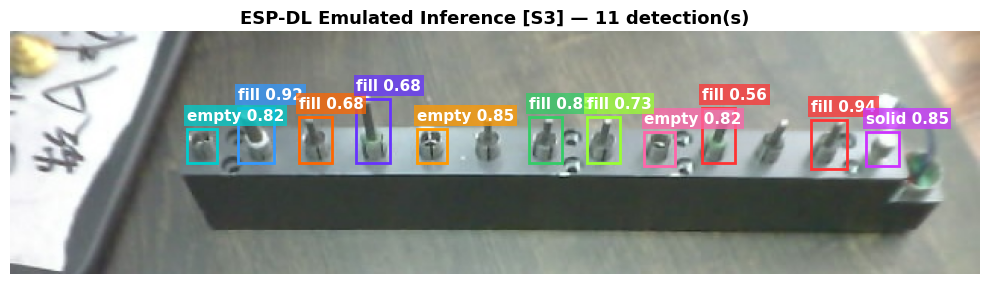


Detections (11):
  [  0] fill                  conf=0.940  box=[528, 58, 552, 90]
  [  0] fill                  conf=0.924  box=[150, 50, 174, 86]
  [  0] fill                  conf=0.852  box=[342, 56, 364, 86]
  [  1] empty                 conf=0.852  box=[268, 64, 288, 86]
  [  2] solid                 conf=0.852  box=[564, 66, 586, 88]
  [  1] empty                 conf=0.818  box=[116, 64, 136, 86]
  [  1] empty                 conf=0.818  box=[418, 66, 438, 88]
  [  0] fill                  conf=0.731  box=[380, 56, 402, 86]
  [  0] fill                  conf=0.679  box=[190, 56, 212, 86]
  [  0] fill                  conf=0.679  box=[228, 44, 250, 86]
  [  0] fill                  conf=0.562  box=[456, 50, 478, 86]


In [21]:
# ==========================================
# CELL 10.1: Inference Preview (ESP-DL Emulated)
# ==========================================
# Runs the quantized graph on a test image using the same preprocessing
# as the ESP-DL C++ runtime (nearest-neighbour resize + letterbox padding,
# pad_val=114 — matching YOLO26::preprocess() in yolo26.cpp).
#
# Post-processing mirrors YOLO26::postprocess() + YOLO26::decode_grid()
# from esp-dl/models/yolo26/yolo26.cpp exactly:
#   - Sigmoid applied to raw cls scores
#   - Box decoded as: x1=(cx+0.5 - d_l)*stride, x2=(cx+0.5 + d_r)*stride
#   - YOLOv26 one2one head is NMS-FREE: top-K sort by score only
#
# Output filename follows the .espdl export convention:
#   <stem>_<img_sz>_s8_<platform>.jpg   e.g. bus_512_s8_p4.jpg
%matplotlib inline
from notebook_helpers import eval_espdl_model
import os

TEST_IMAGE = os.path.join(QATConfig.BASE_DIR, "results", "src_008.jpg")
OUTPUT_DIR = os.path.join(QATConfig.BASE_DIR, "results")

img_sz = (QATConfig.IMG_SZ_H, QATConfig.IMG_SZ_W)

print("type is ", type(img_sz))

predictions, saved_path = eval_espdl_model(
    test_image_path = TEST_IMAGE,
    graph           = graph,
    target_img_sz   = img_sz,
    data_yaml       = QATConfig.DATA_YAML_FILE,
    platform        = PLATFORM,
    conf_thresh     = 0.2,
    output_dir      = OUTPUT_DIR,
)

print(f"\nDetections ({len(predictions)}):")
for p in predictions:
    print(f"  [{p['class_id']:3d}] {p['class']:20s}  conf={p['score']:.3f}  box={[round(v) for v in p['box']]}")


In [20]:
# ==========================================
# CELL 11: Final Export
# ==========================================
final_espdl_path = os.path.join(QATConfig.ESPDL_OUTPUT_DIR, f"yolo26n_{QATConfig.IMG_SZ_H}_{QATConfig.IMG_SZ_W}_s8_{PLATFORM}.espdl")

# Using the Local Advanced Exporter that fixes the Pivot bug natively
exporter = PFL.Exporter(platform=QATConfig.TARGET_PLATFORM)
exporter.export(final_espdl_path, graph=graph, int16_lut_step=QATConfig.INT16_LUT_STEP)
print(f"Deployment Model exported seamlessly to {final_espdl_path}")

[ESPDL Exporter] Switching to IDEAL MATH for Table Generation...
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip val_3 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_12 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_3 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_0 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_1 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_6 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_8 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_16 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip softmax because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip PPQ_Variable_10 because it's not exportable
[INFO][ESPDL][2026-05-25 15:11:28]:  Skip  because it's not exportable
[INFO][ESPDL][2026-05-25 15